<a href="https://colab.research.google.com/github/oyinodun/Customer_Return_Prediction/blob/main/Customer_return_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [28]:
#importing the data to colab
data_path = '/content/online_retail_II.xlsx'
Cusret= pd.read_excel(data_path)

In [29]:
Cusret.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


**To understand the number of rows, columns, data types, and missing values, we carry out EDA**

In [30]:
Cusret.shape

(525461, 8)

In [31]:
Cusret.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [32]:
Cusret.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [33]:
#Removing rows without customer ID and rows where quantity is zero
Cusret = Cusret.dropna(subset=["Customer ID"])
Cusret = Cusret[Cusret["Quantity"] != 0]

Cusret["Customer ID"] = Cusret["Customer ID"].astype(int)

Cusret.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


**Since a returned or cancelled orders usually have negative quantity, a new column will be created to identify a return indicator**

In [34]:
Cusret["is_return"] = np.where(Cusret["Quantity"] < 0, 1, 0)
Cusret["is_return"].value_counts()

#return item = 1
#normal purchase = 0

,count
is_return,
0,407695
1,9839


In [35]:
#Creating a revenue column to understand the value of each transaction
Cusret["Revenue"] = Cusret["Quantity"] * Cusret["Price"]

Cusret.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_return,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,0,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,0,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,0,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,0,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,0,30.0


**To change the dataset from transaction-level to customer-level so that each row now represents one customer.**

In [36]:
customer_df = Cusret.groupby("Customer ID").agg(
    total_orders=("Invoice", "nunique"),
    total_items=("Quantity", "sum"),
    total_spent=("Revenue", "sum"),
    avg_order_value=("Revenue", "mean"),
    total_returns=("is_return", "sum"),
    unique_products=("StockCode", "nunique")
).reset_index()

customer_df.head()

,Customer ID,total_orders,total_items,total_spent,avg_order_value,total_returns,unique_products
0,12346,15,52,-64.68,-1.406087,13,29
1,12347,2,828,1323.32,18.638310,0,70
2,12348,1,373,222.16,11.108000,0,20
3,12349,4,988,2646.99,24.738224,5,92
4,12351,1,261,300.93,14.330000,0,21


In [37]:
#Creating return rate in other to know how often a customer returns products compared to their total number of orders.
customer_df["return_rate"] = customer_df["total_returns"] / customer_df["total_orders"]
customer_df.head()

,Customer ID,total_orders,total_items,total_spent,avg_order_value,total_returns,unique_products,return_rate
0,12346,15,52,-64.68,-1.406087,13,29,0.866667
1,12347,2,828,1323.32,18.638310,0,70,0.000000
2,12348,1,373,222.16,11.108000,0,20,0.000000
3,12349,4,988,2646.99,24.738224,5,92,1.250000
4,12351,1,261,300.93,14.330000,0,21,0.000000


**Customers in the top 25% of return rate are labeled as high-return customers.**

In [38]:
#Defining high-return customers
threshold = customer_df["return_rate"].quantile(0.75)

customer_df["high_return_customer"] = np.where(
    customer_df["return_rate"] >= threshold,
    1,
    0
)
customer_df["high_return_customer"].value_counts()

,count
high_return_customer,
0,3148
1,1235


Selecting features and target

x contains the features used to predict

y is the outcome we want the model to predict

In [39]:
X = customer_df[
    [
        "total_orders",
        "total_items",
        "total_spent",
        "avg_order_value",
        "unique_products"
    ]
]

y = customer_df["high_return_customer"]

Spliting into training and testing data

80% of data goes to training and 20% to test it

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Training Random forest model**

In [41]:
# class_weight ="balanced" helps if one class is much smaller than the other
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [42]:
#To get the predicted class and the probability that a customer is high-return

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

**Model Evaluation**

To get information on the performace of the model, we carry out the following analysis

Precision: Of customers predicted as high-return, how many truly were?

Recall: Of all actual high-return customers, how many did the model catch?

F1-score: Balance between precision and recall.

ROC-AUC: How well the model separates high-return vs low-return customers.

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7320410490307868


In [44]:
print(confusion_matrix(y_test, y_pred))

[[453 177]
 [ 58 189]]


In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.72      0.79       630
           1       0.52      0.77      0.62       247

    accuracy                           0.73       877
   macro avg       0.70      0.74      0.71       877
weighted avg       0.78      0.73      0.74       877



In [46]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.8315018315018314


To show which features influenced the model the most.

In [47]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,total_orders,0.376774
3,avg_order_value,0.201824
2,total_spent,0.163961
1,total_items,0.144346
4,unique_products,0.113095


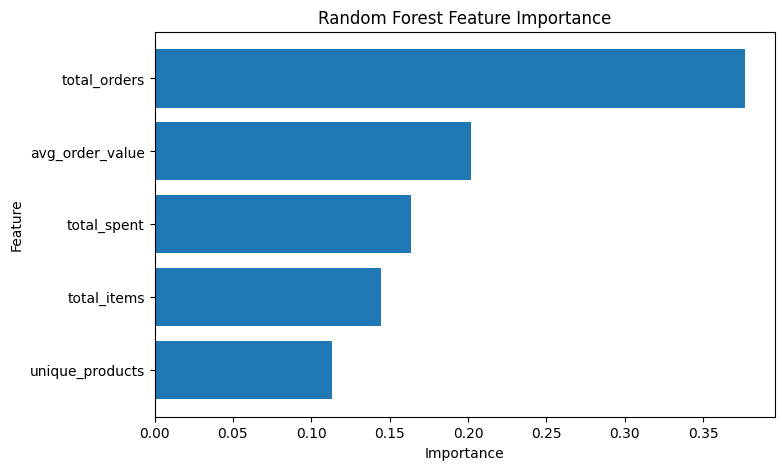

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

**Saving model outputs**

In [49]:
results = X_test.copy()

results["actual_high_return"] = y_test.values
results["predicted_high_return"] = y_pred
results["high_return_probability"] = y_prob

results.head()

,total_orders,total_items,total_spent,avg_order_value,unique_products,actual_high_return,predicted_high_return,high_return_probability
4090,2,152,366.00,19.263158,19,0,0,0.393930
3812,1,111,189.47,3.211356,55,0,0,0.002534
2182,8,686,1076.52,7.475833,108,1,1,0.607469
3809,2,186,645.60,53.800000,12,0,0,0.195882
2029,12,2208,3412.78,27.746179,56,0,1,0.583826


In [50]:
results.to_csv("customer_return_predictions.csv", index=False)